In [9]:
import pandas as pd
import json

In [10]:
with open("../data/daikibo-telemetry-data.json") as f:
    raw_data = json.load(f)

df = pd.json_normalize(
    raw_data,
    sep="_" 
)

df.head()

,deviceID,deviceType,timestamp,location_country,location_city,location_area,location_factory,location_section,data_status,data_temperature
0,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619816400000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27
1,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619817000000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27
2,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619817600000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,26
3,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619818200000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,24
4,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619818800000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27


In [11]:
df["downtime"] = df["data_status"].apply(lambda x: 10 if x=="unhealthy" else 0)
df.head()

,deviceID,deviceType,timestamp,location_country,location_city,location_area,location_factory,location_section,data_status,data_temperature,downtime
0,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619816400000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27,0
1,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619817000000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27,0
2,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619817600000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,26,0
3,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619818200000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,24,0
4,19ff3161-2b3a-40a3-8604-bdc6532d0dab,CNC,1619818800000,japan,tokyo,keiyō-industrial-zone,daikibo-factory-meiyo,section-1,healthy,27,0


In [12]:
# Group by Factory
factory_downtime = df.groupby("location_factory")["downtime"].sum().sort_values(ascending=False)
print(factory_downtime)

location_factory
daikibo-factory-seiko    480
daikibo-shenzhen         420
daikibo-factory-meiyo    110
daikibo-berlin            20
Name: downtime, dtype: int64


In [13]:
worst_factory = factory_downtime.idxmax()

df_worst = df[df["location_factory"] == worst_factory]

device_downtime = df_worst.groupby("deviceType")["downtime"].sum().sort_values(ascending=False)
print(device_downtime)

deviceType
LaserWelder       480
AirWrench           0
CNC                 0
ConveyorBelt        0
Furnace             0
HeavyDutyDrill      0
LaserCutter         0
MetalPress          0
SpotWelder          0
Name: downtime, dtype: int64


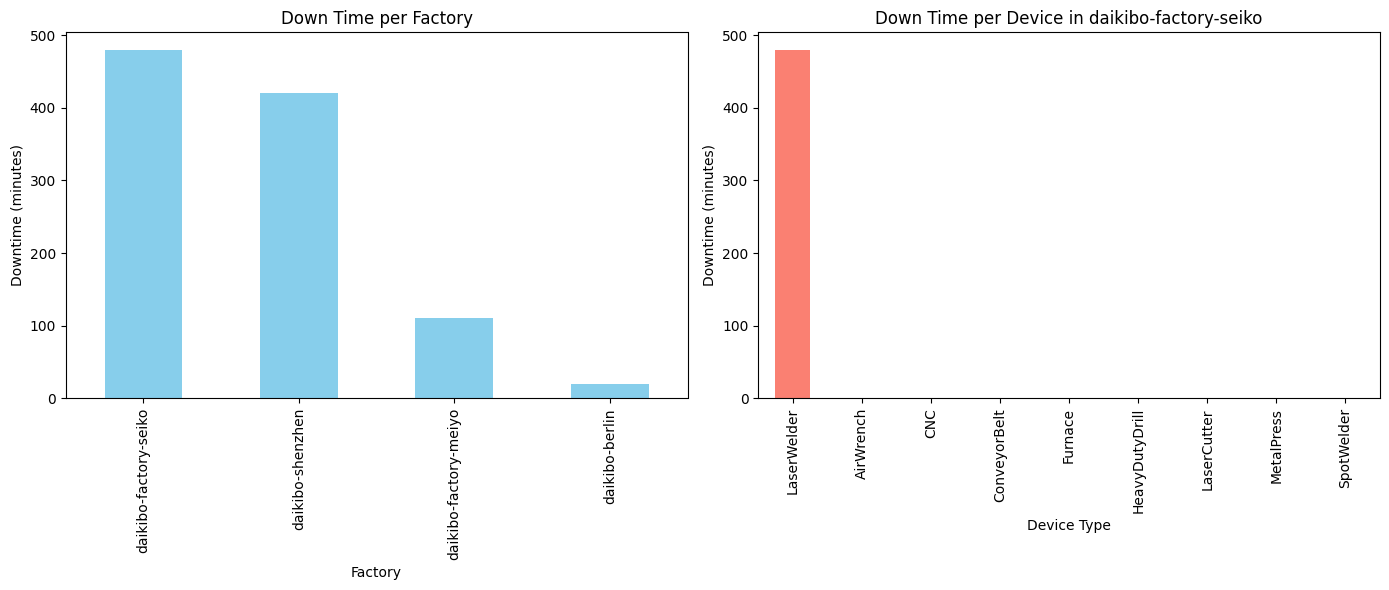

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# fig 1：Down Time per Factory
factory_downtime.plot(kind='bar', ax=axes[0], color='skyblue', title='Down Time per Factory')
axes[0].set_ylabel('Downtime (minutes)')
axes[0].set_xlabel('Factory')

# fig 2：Down Time per Device in Worst Factory
device_downtime.plot(kind='bar', ax=axes[1], color='salmon', title=f'Down Time per Device in {worst_factory}')
axes[1].set_ylabel('Downtime (minutes)')
axes[1].set_xlabel('Device Type')

# Adjust layout
plt.tight_layout()

# Save images
plt.savefig('../images/factory_device_downtime_py.png', dpi=300)

plt.show()